Visualizations to understand what is done in simulate.py

In [92]:
# importations
# public
import numpy as np
import matplotlib.pyplot as plt

# local
from dual_spls.simulate import simulate

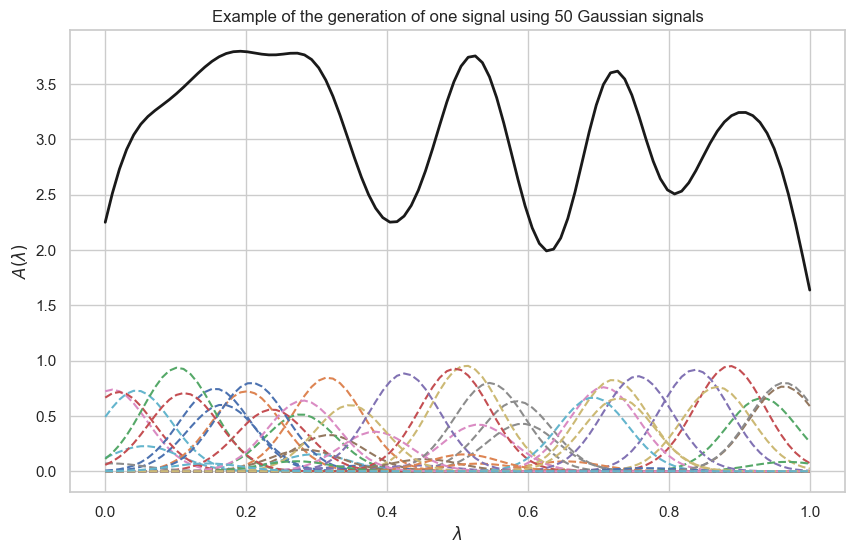

In [93]:
# one signal

p = 100
nondes = 50
sigmaondes = 0.05

x_local = np.linspace(0, 1, p)
amplitudes = np.random.uniform(0, 1, nondes)
modes = np.random.uniform(0, 1, nondes)

signal = np.zeros(p)
for j in range(nondes):
    gauss = amplitudes[j] * np.exp(-(x_local - modes[j])**2 / (2 * sigmaondes**2))  
    signal += gauss

    plt.plot(x_local, gauss, "--")

plt.xlabel("$\lambda$")
plt.ylabel("$A(\lambda)$")
plt.title("Example of the generation of one signal using 50 Gaussian signals")
plt.plot(x_local, signal, "k-", linewidth=2, label="Total Signal")
plt.show()


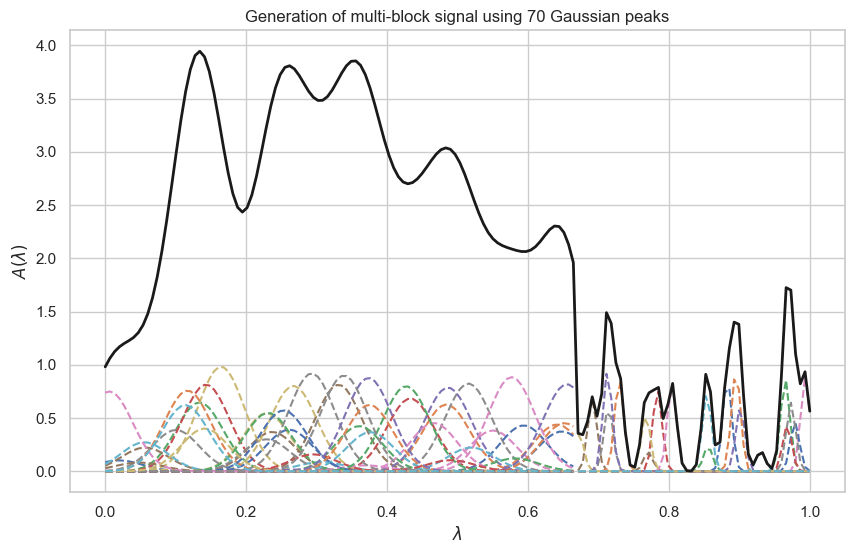

In [94]:
# generate len(p) signals to be concatenated:
p = [100, 50]
nondes = [50, 20]
sigmaondes = [0.05, 0.02]

begin = 0
signal = np.zeros(sum(p))
x_full  = np.linspace(0, 1, sum(p))
for k in range(len(p)):
    # generation of random amplitudes and mode for the gaussians
    current_x_range = x_full[begin : begin + p[k]]
    x_local = np.linspace(0, 1, p[k])
    amplitudes = np.random.uniform(0, 1, nondes[k])
    modes = np.random.uniform(0, 1, nondes[k])

    # build signal
    for j in range(nondes[k]):
        gauss = amplitudes[j] * np.exp(-(x_local - modes[j])**2 / (2 * sigmaondes[k]**2)) 
        signal[begin: begin+p[k]] += gauss

        plt.plot(current_x_range, gauss, "--")
        
    begin += p[k] # shift of p[k] to be able to concatenate the signals in the next iteration

plt.xlabel("$\lambda$")
plt.ylabel("$A(\lambda)$")
plt.title(f"Generation of multi-block signal using {sum(nondes)} Gaussian peaks")
plt.plot(x_full, signal, "k-", linewidth=2, label="Total Signal")
plt.show()